# **Remarriage After Divorce Proof of Concept**

#### **Team Members:** Khadiatou Ly & Zainab Atanda

##### Class: Machine Learning II (DS 4420)
##### Professor Gerber

In [ ]:
# libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

/Users/kadely/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [ ]:
# loading files
fem = pd.read_csv("NSFG_2022_2023_FemRespPUFData.csv")
male = pd.read_csv("NSFG_2022_2023_MaleRespPUFData.csv")

print(fem.shape)
print(male.shape)

(5586, 1912)
(4371, 1157)


## **Cleaning**

We will synthesize the datasets and add a sex column. Once filtered for divorved individuals, we will further extract the data based on the socioeconomic factors used to conduct the analysis.

In [ ]:
# extracting female and male divorcees
fem_div  = fem[fem["MARENDHX_1"] == 2].copy()
male_div = male[male["MARREND_1"] == 2].copy()

fem_div["remarried"]  = fem_div["WHMARHX_Y_2"].notna().astype(int)
male_div["remarried"] = male_div["MARDATEN_Y_2"].notna().astype(int)

print(f"\nFemale divorced: {len(fem_div)}  |  remarried: {fem_div['remarried'].sum()}")
print(f"Male   divorced: {len(male_div)}  |  remarried: {male_div['remarried'].sum()}")



Female divorced: 609  |  remarried: 306
Male   divorced: 37  |  remarried: 0


In [ ]:
# pulling cols to keep
factors  = ["AGE_R", "POVERTY", "TOTINCR", "HIEDUC",
               "LABORFOR", "RSCRRACE", "HISP", "remarried"]

# changing col name to num_children
fem_div["num_children"]  = fem_div["NUMCHILD"]
male_div["num_children"] = male_div["NUMBIOKID"]


fem_div["sex"]  = 1
male_div["sex"] = 0

# combining to one common column list, then  into a single dataset
keep = factors + ["num_children", "sex"]
remarriage_data = pd.concat([fem_div[keep], male_div[keep]], ignore_index=True)

# standardizing col names
remarriage_data = remarriage_data.rename(columns={
    "AGE_R"    : "age",
    "POVERTY"  : "poverty_ratio",
    "TOTINCR"  : "total_income_cat",
    "HIEDUC"   : "education_level",
    "LABORFOR" : "labor_force_status",
    "RSCRRACE" : "race",
    "HISP"     : "hispanic",
})

print(f"\nCombined dataset: {remarriage_data.shape[0]} rows, {remarriage_data.shape[1]} columns")


Combined dataset: 646 rows, 10 columns


In [ ]:
# replacing NFSG codes with NAN
remarriage_data["hispanic"] = remarriage_data["hispanic"].replace({8: np.nan, 9: np.nan})
remarriage_data["num_children"] = remarriage_data["num_children"].replace({98: np.nan, 99: np.nan})
remarriage_data["age"] = remarriage_data["age"].where(remarriage_data["age"] < 95, np.nan)
remarriage_data["poverty_ratio"] = remarriage_data["poverty_ratio"].where(remarriage_data["poverty_ratio"] <= 700, np.nan)

# recoding categorical variables

# hispanic - binary: 1 = Hispanic, 0 = not Hispanic
remarriage_data["hispanic"] = remarriage_data["hispanic"].map({1: 1, 5: 0})

# labor_force_status - binary: employed (codes 1–3) vs. not employed (codes 4–7)
remarriage_data["employed"] = remarriage_data["labor_force_status"].apply(
    lambda x: 1 if x in [1, 2, 3] else (0 if x in [4, 5, 6, 7] else np.nan)
)
remarriage_data = remarriage_data.drop(columns=["labor_force_status"])

# race - one-hot encode (White = reference category, dropped)
race_dummies = pd.get_dummies(remarriage_data["race"], drop_first=True, dummy_na=False)
race_dummies.columns = ["race_black", "race_aian", "race_asian_pi"]
remarriage_data = pd.concat([remarriage_data.drop(columns=["race"]), race_dummies.astype(float)], axis=1)

# imputing remaining NAN with median
for col in remarriage_data.columns:
    if remarriage_data[col].isna().any():
        remarriage_data[col] = remarriage_data[col].fillna(remarriage_data[col].median())

# check
assert remarriage_data.isna().sum().sum() == 0, "NO NaNs"
print("\nCleaning complete")
print(f"Remarried: {remarriage_data['remarried'].mean():.1%} | Not: {1 - remarriage_data['remarried'].mean():.1%}")
print(f"Final feature columns: {[c for c in remarriage_data.columns if c != 'remarried']}")


Cleaning complete
Remarried: 47.4% | Not: 52.6%
Final feature columns: ['age', 'poverty_ratio', 'total_income_cat', 'education_level', 'hispanic', 'num_children', 'sex', 'employed', 'race_black', 'race_aian', 'race_asian_pi']


## **Preprocessing for MLP**
We are splitting, testing, and training the data into their respective sets. Then we split into two class––remarried and not remarried

In [ ]:
# features
features = ["age", "poverty_ratio", "total_income_cat", "education_level",
                "num_children", "hispanic", "sex", "employed",
                "race_black", "race_aian", "race_asian_pi"]

X = remarriage_data[features].values.astype(float)
y = remarriage_data["remarried"].values.astype(float)

In [ ]:
# standardizing parameters
def standardize(X_train, X_test):
    mu  = X_train.mean(axis=0)
    std = X_train.std(axis=0)
    std[std == 0] = 1
    return (X_train - mu) / std, (X_test - mu) / std

# train, test, and split
np.random.seed(42)
pos_idx = np.where(y == 1)[0]
neg_idx = np.where(y == 0)[0]

# spliting into remarried and not remarried classes
def split_class(idx, frac=0.8):
    np.random.shuffle(idx)
    c = int(len(idx) * frac)
    return idx[:c], idx[c:]

pos_train, pos_test = split_class(pos_idx)
neg_train, neg_test = split_class(neg_idx)

train_idx = np.concatenate([pos_train, neg_train])
test_idx  = np.concatenate([pos_test,  neg_test])

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

X_train, X_test = standardize(X_train, X_test)
print(f"\nTraining set size: {len(X_train)}  |  Testing set size: {len(X_test)}")


Training set size: 516  |  Testing set size: 130


## **MLP**
We are now implementing an MLP manually.

- Architecture: Input → Hidden (32 neurons, ReLU) → Output (1 neuron, Sigmoid)
- Loss:         Binary Cross-Entropy
- Optimizer:    Mini-batch Stochastic Gradient Descent (SGD)

In [ ]:
# activation functions
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

# loss function
def binary_cross_entropy(y_true, y_pred):
    y_pred = np.clip(y_pred, 1e-9, 1 - 1e-9)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

In [ ]:
# hyperparameters
N_INPUT   = X_train.shape[1]
N_HIDDEN  = 32
N_OUTPUT  = 1
LR        = 0.01
EPOCHS    = 200
BATCH_SIZE = 32

# weights
np.random.seed(42)
W1 = np.random.randn(N_INPUT,  N_HIDDEN) * np.sqrt(2.0 / N_INPUT)
b1 = np.zeros((1, N_HIDDEN))
W2 = np.random.randn(N_HIDDEN, N_OUTPUT) * np.sqrt(2.0 / N_HIDDEN)
b2 = np.zeros((1, N_OUTPUT))

In [ ]:
loss_history = []

for epoch in range(EPOCHS):

    # shuffles training data each epoch
    perm = np.random.permutation(len(X_train))
    X_shuf, y_shuf = X_train[perm], y_train[perm]

    epoch_losses = []

    for start in range(0, len(X_train), BATCH_SIZE):
        Xb = X_shuf[start : start + BATCH_SIZE]
        yb = y_shuf[start : start + BATCH_SIZE, None]

# forward pass
        Z1 = Xb @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)

        loss = binary_cross_entropy(yb, A2)
        epoch_losses.append(loss)

# backward pass
        B = len(Xb)

        # Output layer gradient
        dA2 = (A2 - yb) / B
        dW2 = A1.T @ dA2
        db2 = dA2.sum(axis=0, keepdims=True)

        # Hidden layer gradient
        dA1 = dA2 @ W2.T
        dZ1 = dA1 * relu_derivative(Z1)

        dW1 = Xb.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)

# update weights
        W2 -= LR * dW2
        b2 -= LR * db2
        W1 -= LR * dW1
        b1 -= LR * db1

    loss_history.append(np.mean(epoch_losses))

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  |  Loss: {loss_history[-1]:.4f}")

# forward pass on test data
Z1_test = X_test @ W1 + b1
A1_test = relu(Z1_test)
Z2_test = A1_test @ W2 + b2
y_proba = sigmoid(Z2_test).flatten()

# converting probabilities to class predictions
y_pred = (y_proba >= 0.5).astype(int)

Epoch  50/200  |  Loss: 0.5260
Epoch 100/200  |  Loss: 0.5213
Epoch 150/200  |  Loss: 0.5251
Epoch 200/200  |  Loss: 0.5166


In [ ]:
# evaluating metrics

# accuracy, precision, recall, F1
def confusion(y_true, y_pred):
    TP = np.sum((y_pred == 1) & (y_true == 1))
    TN = np.sum((y_pred == 0) & (y_true == 0))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    return TP, TN, FP, FN

TP, TN, FP, FN = confusion(y_test.astype(int), y_pred)
accuracy  = (TP + TN) / len(y_test)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = (2 * precision * recall / (precision + recall)
             if (precision + recall) > 0 else 0)

def roc_auc(y_true, y_scores):
    # get thresholds from prediction scores
    thresholds = np.sort(np.unique(y_scores))[::-1]
    tpr, fpr = [], []

    # total actual pos and negs
    P = np.sum(y_true)
    N = len(y_true) - P

    # predict 1 if score is at least the threshold
    for t in thresholds:
        pred = (y_scores >= t).astype(int)
        # count true pos and false negs
        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))
        tpr.append(TP / P)
        fpr.append(FP / N)
    auc = np.trapz(tpr, fpr)
    return auc, np.array(fpr), np.array(tpr)

auc, fpr_pts, tpr_pts = roc_auc(y_test.astype(int), y_proba)

In [ ]:
 # test results
print("\n Test Set Results ")
print(f"  Accuracy : {accuracy:.3f}")
print(f"  Precision: {precision:.3f}")
print(f"  Recall   : {recall:.3f}")
print(f"  F1 Score : {f1:.3f}")
print(f"  ROC-AUC  : {auc:.3f}")
print(f"\n  Confusion Matrix:")
print(f"             Pred 0   Pred 1")
print(f"  Actual 0:   {TN:>4}     {FP:>4}")
print(f"  Actual 1:   {FN:>4}     {TP:>4}")



── Test Set Results ─────────────────────────────────────────
  Accuracy : 0.646
  Precision: 0.608
  Recall   : 0.726
  F1 Score : 0.662
  ROC-AUC  : 0.676

  Confusion Matrix:
             Pred 0   Pred 1
  Actual 0:     39       29
  Actual 1:     17       45


## **Plots (drafts)**


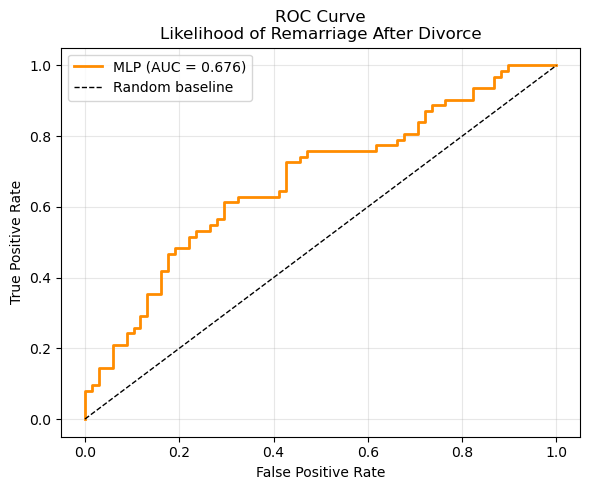

In [ ]:
# roc curve
plt.figure(figsize=(6, 5))
plt.plot(fpr_pts, tpr_pts, color="darkorange", linewidth=2,
         label=f"MLP (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve\nLikelihood of Remarriage After Divorce")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

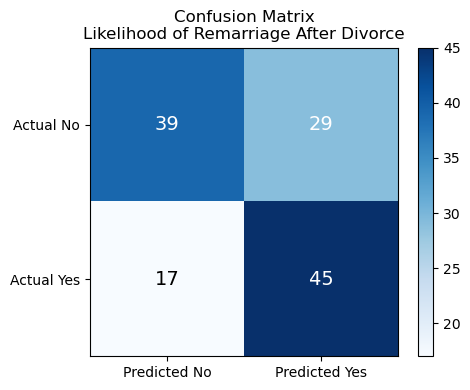

In [ ]:
# confusion matrix
cm = np.array([[TN, FP],
               [FN, TP]])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()
plt.xticks([0, 1], ["Predicted No", "Predicted Yes"])
plt.yticks([0, 1], ["Actual No", "Actual Yes"])
plt.title("Confusion Matrix\nLikelihood of Remarriage After Divorce")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 fontsize=14, color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()

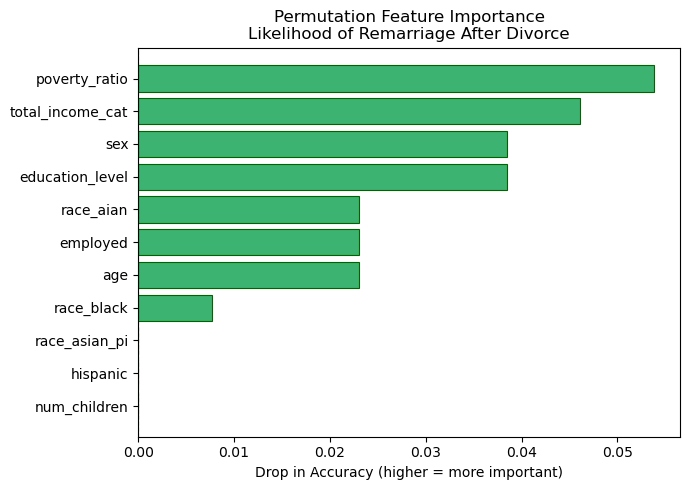

In [ ]:
# feature importance plot
baseline_acc = np.mean((y_proba >= 0.5).astype(int) == y_test.astype(int))
importance = []
for i in range(X_test.shape[1]):
    X_permuted = X_test.copy()
    np.random.shuffle(X_permuted[:, i])

    #  forward pass on the permuted input
    A1_perm   = relu(X_permuted @ W1 + b1)
    perm_proba = sigmoid(A1_perm @ W2 + b2).flatten()
    perm_acc  = np.mean((perm_proba >= 0.5).astype(int) == y_test.astype(int))
    importance.append(baseline_acc - perm_acc)

# sorting features by importance for a cleaner chart
importance     = np.array(importance)
sorted_idx     = np.argsort(importance)
sorted_names   = [features[i] for i in sorted_idx]
sorted_imp     = importance[sorted_idx]

plt.figure(figsize=(7, 5))
plt.barh(sorted_names, sorted_imp, color="mediumseagreen", edgecolor="darkgreen", linewidth=0.8)
plt.axvline(0, color="darkgreen", linewidth=0.8, linestyle="--")
plt.xlabel("Drop in Accuracy (higher = more important)")
plt.title("\nLikelihood of Remarriage After Divorce")
plt.tight_layout()
plt.show()